In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

TRAIN_DATA = pd.read_csv('A3_data/train.csv')
TEST_DATA = pd.read_csv('A3_data/test.csv')

count_vectorizer = CountVectorizer(max_features=5000, stop_words='english')

VECTORIZED_TRAIN_DATA  = count_vectorizer.fit_transform(TRAIN_DATA['Article'])
VECTORIZED_TEST_DATA = count_vectorizer.fit_transform(TEST_DATA['Article'])

## 2(c) SVM (Support Vector Machine)

#### Soft-Margin linear SVM & Hard-Margin RBF kernel SVM

We will use PCA for dimensionality reduction to 2D. This is so we can plot the decision boundaries in 2D space, and we use PCA for this because it preserves as much variation as possible in the data, so even when we reduce the dimension of the data significantly, we will still be able to see the impact of the choices of hyperparameter values (C and Gamma) in the results.

From our plotted results, we can see the following;

The parameter C basically controls how much the Soft-Margin linear SVM cares about misclassifications. At a low C of 0.001, the model is super lazy and tolerant of errors, which gives you a really wide margin where tons of points overlap and cross the line. But when you increase C to 100, the margin gets squeezed incredibly narrow because the model forces itself to separate the clusters as strictly as possible. For the Hard-Margin RBF kernel, Gamma controls how far the influence of each point reaches. A tiny Gamma of 0.005 means points have a huge footprint, giving a smooth, natural-looking curved boundary. When increase Gamma to 0.5, that footprint shrinks, forcing the boundary to gets much more jagged and twists around individual data points and even creates isolated loops around outliers, meaning it is very overfitted.

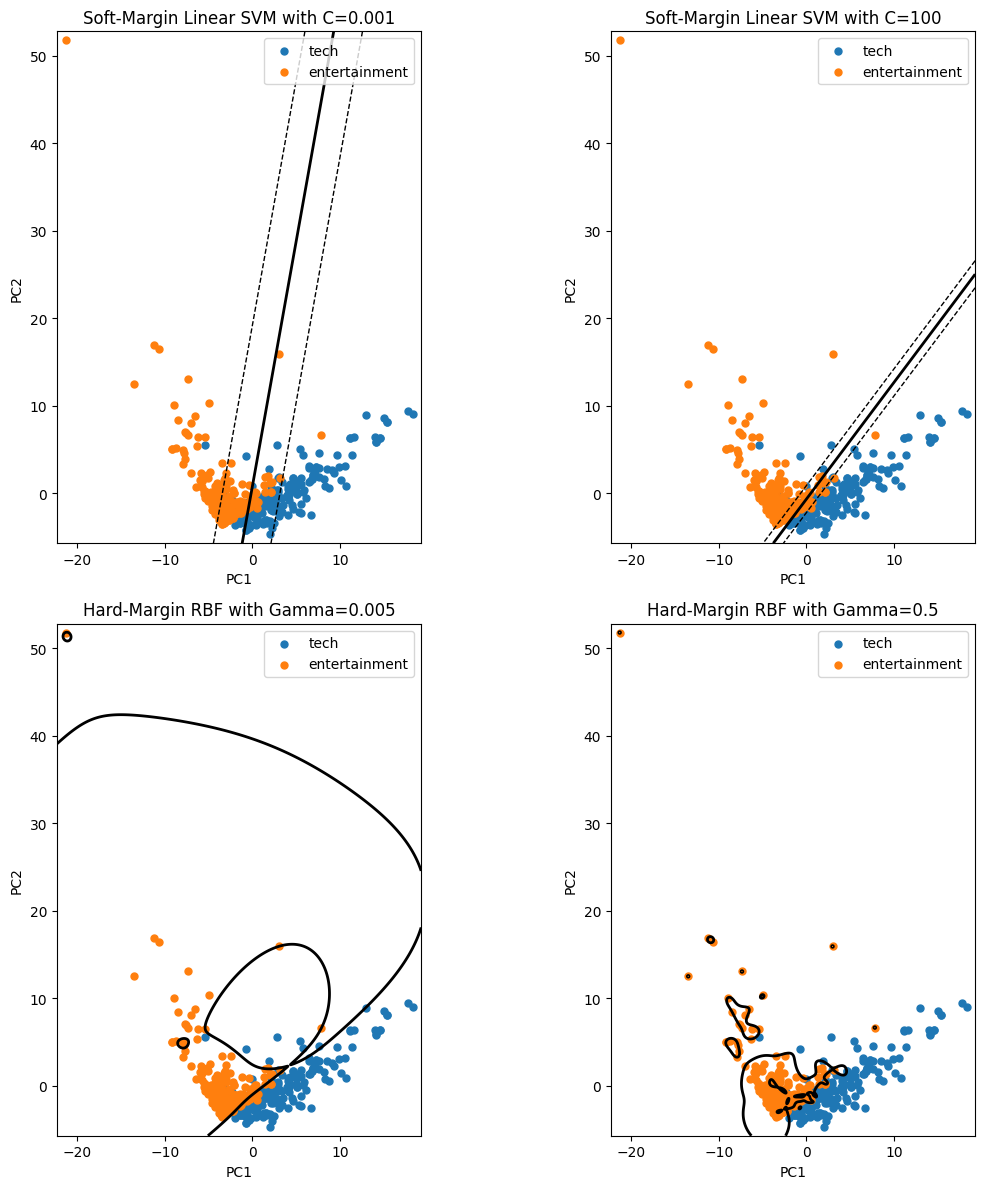

In [2]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

LOW_C = 0.001
HIGH_C = 100
LOW_GAMMA = 0.005
HIGH_GAMMA = 0.5

# dimensionality reduction to 2D via PCA
pca = PCA(n_components=2)
train_data_2D = pca.fit_transform(VECTORIZED_TRAIN_DATA.toarray())

models = []
models.append((SVC(kernel='linear', C=LOW_C).fit(train_data_2D, TRAIN_DATA['Category']), f'Soft-Margin Linear SVM with C={LOW_C}'))
models.append((SVC(kernel='linear', C=HIGH_C).fit(train_data_2D, TRAIN_DATA['Category']), f'Soft-Margin Linear SVM with C={HIGH_C}'))
models.append((SVC(kernel='rbf', C=1e9, gamma=LOW_GAMMA).fit(train_data_2D, TRAIN_DATA['Category']), f'Hard-Margin RBF with Gamma={LOW_GAMMA}'))
models.append((SVC(kernel='rbf', C=1e9, gamma=HIGH_GAMMA).fit(train_data_2D, TRAIN_DATA['Category']), f'Hard-Margin RBF with Gamma={HIGH_GAMMA}'))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
categories = TRAIN_DATA['Category'].unique()
colors = ['tab:blue', 'tab:orange']
label_to_color = {cat: colors[i] for i, cat in enumerate(categories)}

for i, (model, title) in enumerate(models):
    ax = axes[i]
    h = 0.02
    x_min, x_max = train_data_2D[:, 0].min() - 1, train_data_2D[:, 0].max() + 1
    y_min, y_max = train_data_2D[:, 1].min() - 1, train_data_2D[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    if getattr(model, 'kernel', None) == 'linear':
        ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='black', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    else:
        ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
    for category in categories:
        mask = TRAIN_DATA['Category'] == category
        ax.scatter(train_data_2D[mask, 0], train_data_2D[mask, 1], c=label_to_color[category], label=category, s=25)

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal', adjustable='box')
    ax.legend()

plt.tight_layout()
plt.show()